In [1]:
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import os
import glob


# Load the CSV
df = pd.read_csv(os.path.join('experiments', 'experiments_1_36.csv'))
df.head()

,file_name,bridge_angle,Fr,Fr_ini,plates,cubes,logs,Q[dm],H_up,H_down,...,H_down_corr,pic_side,pic_top,dh,dh_d0,rel_BW,carpet_length_avg,carpet_length_max,exp_id,volume
0,N2_R_2P_F055_h09_25C75L_0HR_R1_4L_225degree,22.5,0.018605,0.55,0.25,0.0,0.75,18.6,100.0,14.3,...,89.0,NaN,NaN,5.0,0.055556,NaN,NaN,NaN,1,0
1,dried debris,22.5,0.018605,0.55,0.25,0.0,0.75,18.6,135.0,14.1,...,87.0,NaN,71.0,42.0,0.466667,NaN,NaN,NaN,1,19
2,NaN,22.5,0.018605,0.55,0.25,0.0,0.75,18.6,142.5,14.1,...,87.0,161.0,72.0,49.5,0.550000,NaN,NaN,NaN,1,38
3,NaN,22.5,0.018605,0.55,0.25,0.0,0.75,18.6,145.5,14.1,...,87.0,163.0,73.0,52.5,0.583333,NaN,NaN,NaN,1,57
4,NaN,22.5,0.018605,0.55,0.25,0.0,0.75,18.6,148.0,14.0,...,86.0,167.0,74.0,56.0,0.622222,0.510638,73,86,1,76


In [2]:


def find_photo(folder, pic_num):
    for ext in ['jpg', 'JPG', 'jpeg', 'JPEG']:
        for padding in [3, 4]:
            pattern = os.path.join(folder, f"*{pic_num:0{padding}d}.{ext}")
            matches = glob.glob(pattern)
            if matches:
                if len(matches) > 1:
                    print(f"Warning: multiple matches found: {matches}, using first.")
                return matches[0]
    raise FileNotFoundError(f"No photo found for number {pic_num} in {folder}")

def inspect_experiment(exp_id_num):
    exp_rows = df[df['exp_id'] == exp_id_num].copy()
    photo_rows = exp_rows.iloc[1:]
    
    print(f"Experiment {exp_id_num} — {len(photo_rows)} photo rows")
    print(f"Condition: {exp_rows.iloc[0]['file_name']}")
    print(f"Bridge angle: {exp_rows.iloc[0]['bridge_angle']} — Froude Number: {exp_rows.iloc[0]['Fr_ini']}")
    print(f"DataFrame indices: {exp_rows.index.tolist()}")
    
    n = len(photo_rows)
    fig, axes = plt.subplots(n, 2, figsize=(12, 5 * n))
    white_img = Image.new('RGB', (640, 480), color='white')
    
    for i, (_, row) in enumerate(photo_rows.iterrows()):
        plates = row['plates']
        cubes = row['cubes']
        logs = row['logs']
        
        for j, (col, folder) in enumerate([
            ('pic_top', os.path.join('photos', '100OLYMP_Top_0502')),
            ('pic_side', os.path.join('photos', '100OLYMP_side_0502'))
        ]):
            ax = axes[i, j]
            label = 'Top' if j == 0 else 'Side'
            
            try:
                pic_num = row[col]
                if pd.isna(pic_num):
                    raise ValueError("NaN")
                path = find_photo(folder, int(pic_num))
                ax.imshow(Image.open(path))
                ax.set_title(f'{label} View (Image {int(pic_num)}) — Vol:{row["volume"]} — P:{plates} C:{cubes} L:{logs}')
            except Exception as e:
                ax.imshow(white_img)
                ax.set_title(f'{label} View — Not found ({e})')
            ax.axis('off')
    
    plt.tight_layout()
    plt.show()





Experiment 24 — 4 photo rows
Condition: N3_R_2P_F0,28_h0,9_0P0C100L_0HR_R1_4L_0HW_22,5Deg
Bridge angle: 22.5 — Froude Number: 0.28
DataFrame indices: [115, 116, 117, 118, 119]


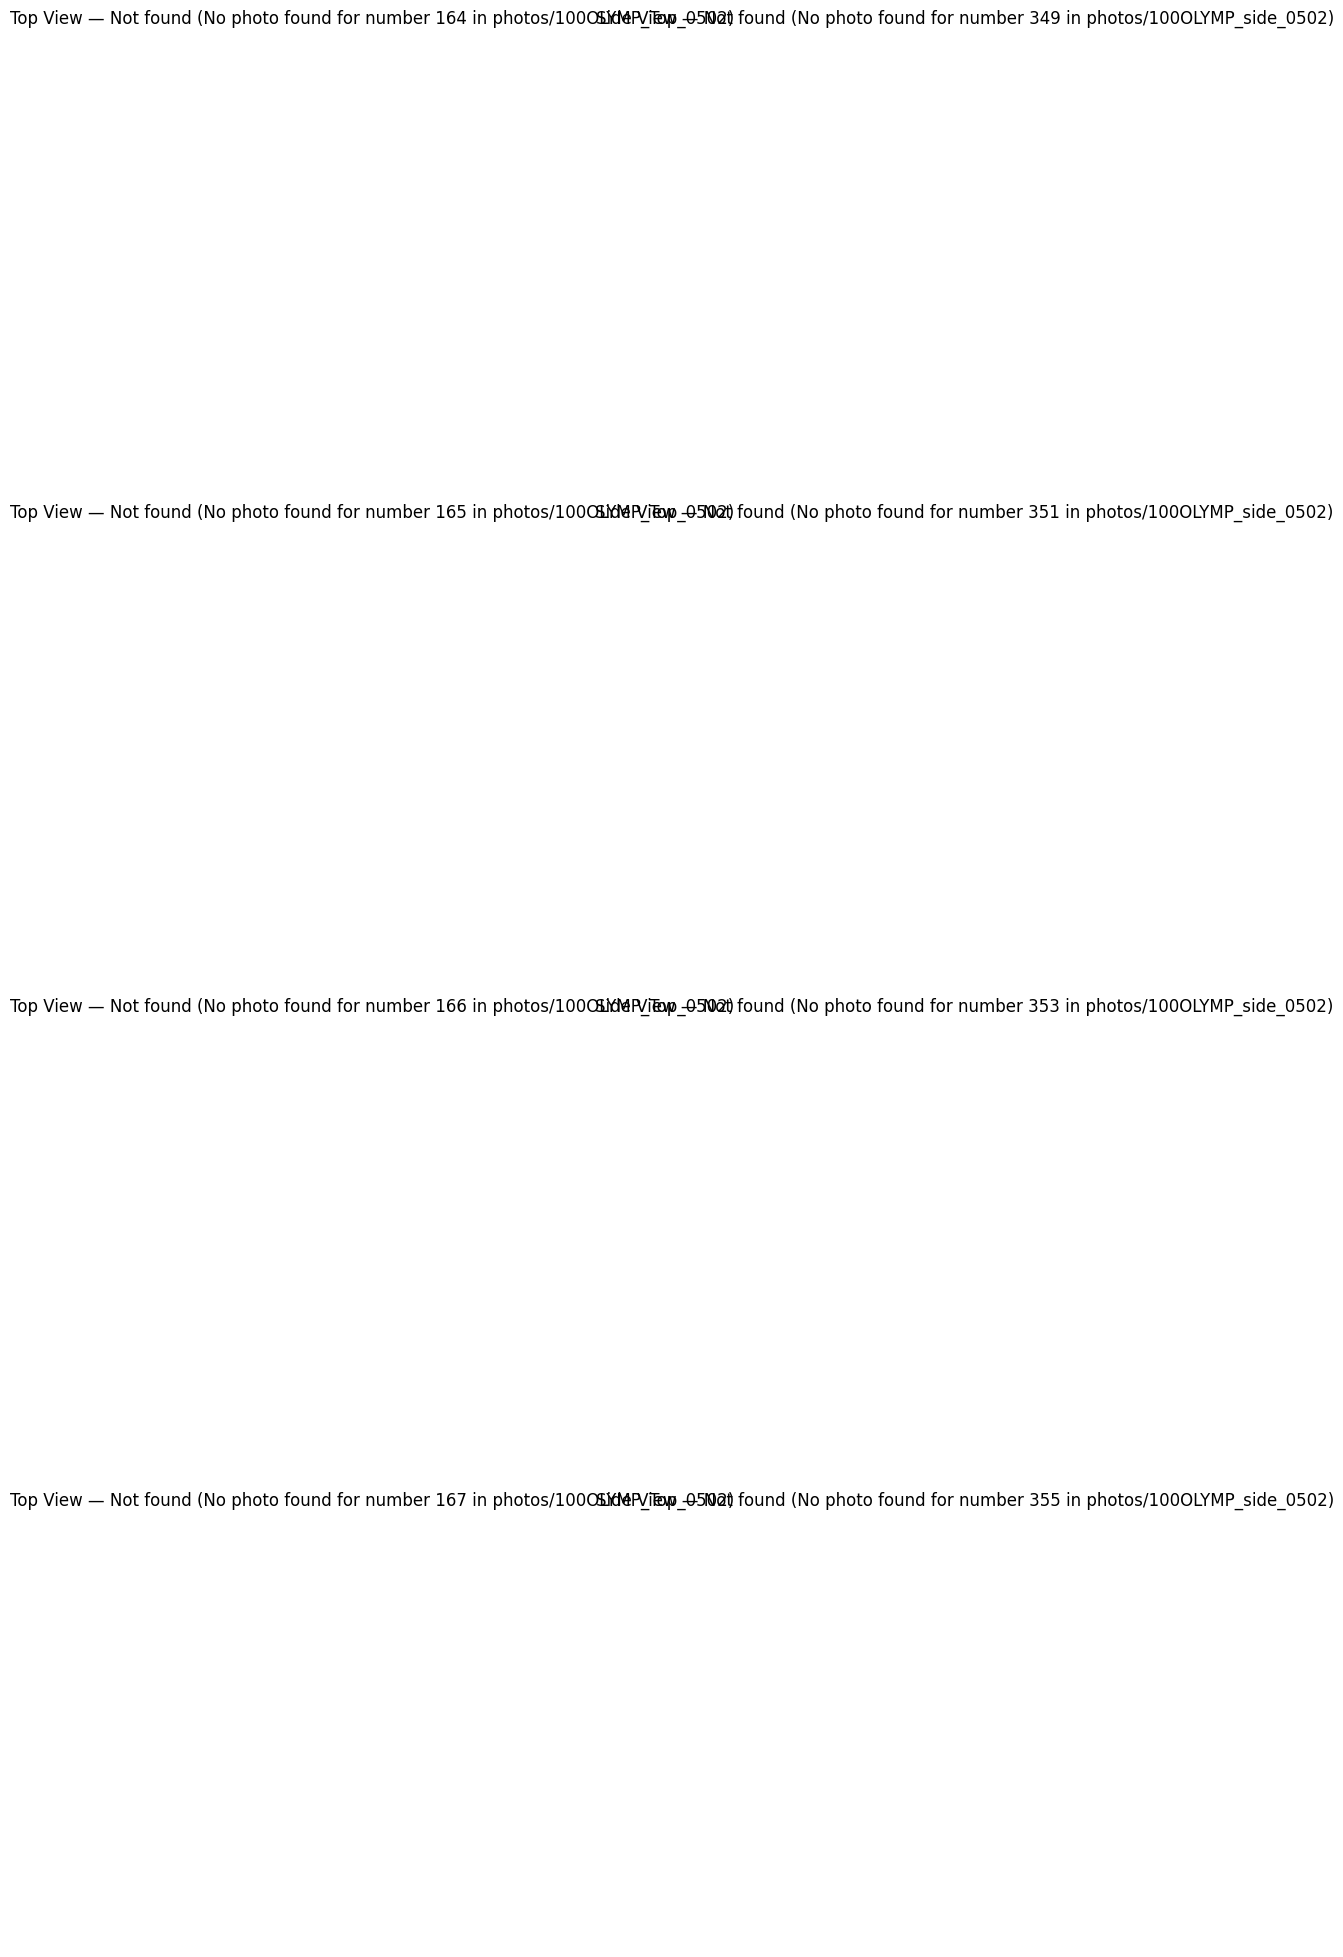

In [3]:
inspect_experiment(24)